In [1]:
# 05_tft_model.ipynb
# ── Cell 1: Imports ────────────────────────────────────────────────────────────
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
import json

PROCESSED_DIR = Path("../data_store/processed")
CHECKPOINT_DIR = Path("../checkpoints/tft")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU    : {props.name}  —  {props.total_memory/1024**3:.1f} GB VRAM")

# Replace the df = pd.read_csv line with:
df = pd.read_csv(
    PROCESSED_DIR / "XAUUSD_5m_historical_features.csv",
    index_col="datetime", parse_dates=True
)
print(f"\nLoaded : {len(df):,} rows × {len(df.columns)} features")
print("\nCell 1 passed ✓")

Device : cuda
GPU    : NVIDIA GeForce RTX 4070  —  12.0 GB VRAM

Loaded : 1,199,260 rows × 47 features

Cell 1 passed ✓


In [2]:
# ── Cell 2: Define feature columns and targets ─────────────────────────────────

# Input features the TFT will see at each timestep
FEATURE_COLS = [
    # Price action
    "open", "high", "low", "close", "volume",
    "candle_body", "candle_range", "body_pct",
    "upper_wick", "lower_wick", "is_bullish",
    # Trend
    "ema_9_ratio", "ema_21_ratio", "ema_50_ratio", "ema_cross",
    # Momentum
    "rsi_14", "rsi_7", "macd", "macd_sig", "macd_hist",
    "stoch_k", "stoch_d",
    # Volatility
    "atr_14", "atr_pct", "bb_width", "bb_pct",
    # Volume
    "volume_ratio",
    # ICT/SMC
    "dist_to_high", "dist_to_low", "hh", "ll", "displacement",
]

# What we're predicting — direction of next bar's close vs current close
# +1 = price goes up, 0 = price goes down
TARGET_COL = "return_1"   # pct change to next bar (already computed)

# Verify all columns exist
missing = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    print(f"!! Missing columns: {missing}")
else:
    print(f"All {len(FEATURE_COLS)} feature columns present ✓")

# Create binary direction target: 1 if next bar closes higher, 0 if lower
df["target_direction"] = (df["return_1"].shift(-1) > 0).astype(float)
df = df.dropna(subset=["target_direction"])

bull_pct = df["target_direction"].mean()
print(f"\nTarget distribution:")
print(f"  Bullish bars : {bull_pct:.1%}")
print(f"  Bearish bars : {1-bull_pct:.1%}")
print(f"  (Should be close to 50/50 for gold)")
print("\nCell 2 passed ✓")

All 32 feature columns present ✓

Target distribution:
  Bullish bars : 49.5%
  Bearish bars : 50.5%
  (Should be close to 50/50 for gold)

Cell 2 passed ✓


In [3]:
# ── Cell 3: Normalisation ──────────────────────────────────────────────────────
# TFTs need normalised input — raw gold prices (4000-5000) would dominate
# We normalise each feature to mean=0 std=1 using training set stats only

SEQUENCE_LEN = 60    # 60 bars lookback = 5 hours of context
TRAIN_SPLIT  = 0.70
VAL_SPLIT    = 0.15
# Test = remaining 15%

n = len(df)
train_end = int(n * TRAIN_SPLIT)
val_end   = int(n * (TRAIN_SPLIT + VAL_SPLIT))

df_train = df.iloc[:train_end]
df_val   = df.iloc[train_end:val_end]
df_test  = df.iloc[val_end:]

print(f"Split sizes:")
print(f"  Train : {len(df_train):,} rows  ({TRAIN_SPLIT:.0%})")
print(f"  Val   : {len(df_val):,} rows  ({VAL_SPLIT:.0%})")
print(f"  Test  : {len(df_test):,} rows  (15%)")

# Compute normalisation stats on TRAIN ONLY
# Never use val/test stats — that would be data leakage
feature_means = df_train[FEATURE_COLS].mean()
feature_stds  = df_train[FEATURE_COLS].std().replace(0, 1)

# Save for inference (so live data gets the same normalisation)
norm_stats = {
    "means": feature_means.to_dict(),
    "stds":  feature_stds.to_dict(),
}
with open("../config/norm_stats.json", "w") as f:
    json.dump(norm_stats, f, indent=2)

print(f"\nNormalisation stats saved to config/norm_stats.json ✓")

# Normalise all splits using TRAIN stats
def normalise(df_split, means, stds):
    out = df_split.copy()
    out[FEATURE_COLS] = (df_split[FEATURE_COLS] - means) / stds
    return out

df_train_n = normalise(df_train, feature_means, feature_stds)
df_val_n   = normalise(df_val,   feature_means, feature_stds)
df_test_n  = normalise(df_test,  feature_means, feature_stds)

# Sanity check — train features should be ~N(0,1)
sample_means = df_train_n[FEATURE_COLS].mean()
sample_stds  = df_train_n[FEATURE_COLS].std()
print(f"\nNormalisation check (train):")
print(f"  Mean of means : {sample_means.mean():.4f}  (should be ~0)")
print(f"  Mean of stds  : {sample_stds.mean():.4f}  (should be ~1)")
print("\nCell 3 passed ✓")

Split sizes:
  Train : 839,482 rows  (70%)
  Val   : 179,889 rows  (15%)
  Test  : 179,889 rows  (15%)

Normalisation stats saved to config/norm_stats.json ✓

Normalisation check (train):
  Mean of means : 0.0000  (should be ~0)
  Mean of stds  : 0.9375  (should be ~1)

Cell 3 passed ✓


In [4]:
# ── Cell 4: Dataset class ──────────────────────────────────────────────────────

class MarketSequenceDataset(Dataset):
    """
    Sliding window dataset.
    Each sample: (sequence of 60 bars of features, target direction)
    """
    def __init__(self, df: pd.DataFrame, seq_len: int = SEQUENCE_LEN):
        self.seq_len = seq_len
        self.X = torch.tensor(
            df[FEATURE_COLS].values, dtype=torch.float32
        )
        self.y = torch.tensor(
            df["target_direction"].values, dtype=torch.float32
        )

    def __len__(self):
        return len(self.X) - self.seq_len

    def __getitem__(self, idx):
        x_seq = self.X[idx : idx + self.seq_len]          # (60, n_features)
        y_val = self.y[idx + self.seq_len]                 # scalar
        return x_seq, y_val


train_ds = MarketSequenceDataset(df_train_n)
val_ds   = MarketSequenceDataset(df_val_n)
test_ds  = MarketSequenceDataset(df_test_n)

train_dl = DataLoader(train_ds, batch_size=64,  shuffle=True,  num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=128, shuffle=False, num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=128, shuffle=False, num_workers=0)

# Shape check
x_sample, y_sample = next(iter(train_dl))
print(f"Batch shapes:")
print(f"  X : {tuple(x_sample.shape)}  (batch, seq_len, features)")
print(f"  y : {tuple(y_sample.shape)}  (batch,)")
print(f"\nDataset sizes:")
print(f"  Train batches : {len(train_dl)}")
print(f"  Val batches   : {len(val_dl)}")
print(f"  Test batches  : {len(test_dl)}")
print("\nCell 4 passed ✓")

Batch shapes:
  X : (64, 60, 32)  (batch, seq_len, features)
  y : (64,)  (batch,)

Dataset sizes:
  Train batches : 13116
  Val batches   : 1405
  Test batches  : 1405

Cell 4 passed ✓


In [5]:
# ── Cell 5: TFT model architecture ────────────────────────────────────────────

class TemporalFusionTransformer(nn.Module):
    """
    Simplified TFT for binary direction prediction.

    Architecture:
      1. Input projection   — linear layer maps features to model_dim
      2. Positional encoding — tells the model where in the sequence each bar is
      3. Transformer encoder — multi-head attention over the sequence
      4. Gated output        — attention pooling over sequence dimension
      5. Classification head — outputs P(next bar is bullish)

    Designed to fit comfortably in 2GB VRAM at training time.
    At inference: <100MB.
    """
    def __init__(
        self,
        n_features:  int = len(FEATURE_COLS),
        model_dim:   int = 64,
        n_heads:     int = 4,
        n_layers:    int = 2,
        seq_len:     int = SEQUENCE_LEN,
        dropout:     float = 0.1,
    ):
        super().__init__()
        self.model_dim = model_dim
        self.seq_len   = seq_len

        # 1. Input projection
        self.input_proj = nn.Sequential(
            nn.Linear(n_features, model_dim),
            nn.LayerNorm(model_dim),
            nn.ReLU(),
        )

        # 2. Positional encoding (learned)
        self.pos_embedding = nn.Embedding(seq_len, model_dim)

        # 3. Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=n_heads,
            dim_feedforward=model_dim * 4,
            dropout=dropout,
            batch_first=True,    # (batch, seq, features)
            norm_first=True,     # pre-norm = more stable training
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers,
        )

        # 4. Attention pooling — learns which timesteps to focus on
        self.attn_pool = nn.Linear(model_dim, 1)

        # 5. Classification head
        self.classifier = nn.Sequential(
            nn.Linear(model_dim, model_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(model_dim // 2, 1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (batch, seq_len, n_features)
        returns: (batch,) — probability of bullish next bar
        """
        B, T, _ = x.shape

        # Project features
        x = self.input_proj(x)                          # (B, T, model_dim)

        # Add positional encoding
        positions = torch.arange(T, device=x.device)
        x = x + self.pos_embedding(positions)           # (B, T, model_dim)

        # Transformer
        x = self.transformer(x)                         # (B, T, model_dim)

        # Attention pooling over time dimension
        attn_weights = torch.softmax(
            self.attn_pool(x), dim=1
        )                                               # (B, T, 1)
        x = (x * attn_weights).sum(dim=1)              # (B, model_dim)

        # Classify
        out = self.classifier(x).squeeze(-1)            # (B,)
        return out


# Instantiate and check
# Replace the model instantiation line with:
model = TemporalFusionTransformer(
    model_dim=128,    # was 64 — more capacity for 1.2M bars
    n_heads=8,        # was 4
    n_layers=3,       # was 2
    dropout=0.15,
).to(device)

# Parameter count
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters : {n_params:,}")
print(f"Approx VRAM      : ~{n_params * 4 / 1024**2:.1f} MB (weights only)")

# Forward pass test
with torch.no_grad():
    test_out = model(x_sample.to(device))
print(f"\nForward pass test:")
print(f"  Input  : {tuple(x_sample.shape)}")
print(f"  Output : {tuple(test_out.shape)}  — values in [{test_out.min():.3f}, {test_out.max():.3f}]")
print(f"  (Output should be 0-1 probabilities)")
print("\nCell 5 passed ✓")

c:\Users\rfsga\miniconda3\envs\nexus\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Model parameters : 615,426
Approx VRAM      : ~2.3 MB (weights only)

Forward pass test:
  Input  : (64, 60, 32)
  Output : (64,)  — values in [0.459, 0.658]
  (Output should be 0-1 probabilities)

Cell 5 passed ✓


In [6]:
# ── Cell 6: Training loop ──────────────────────────────────────────────────────

def train_model(
    model, train_dl, val_dl,
    n_epochs: int = 15,
    lr: float = 1e-3,
    patience: int = 5,         # early stopping
):
    optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimiser, T_max=n_epochs
    )
    criterion = nn.BCELoss()

    best_val_acc  = 0.0
    patience_ctr  = 0
    history       = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, n_epochs + 1):
        # ── Train ──────────────────────────────────────────────────────────────
        model.train()
        train_losses = []

        for x_batch, y_batch in train_dl:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimiser.zero_grad()
            preds = model(x_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()
            train_losses.append(loss.item())

        # ── Validate ───────────────────────────────────────────────────────────
        model.eval()
        val_losses, val_correct, val_total = [], 0, 0

        with torch.no_grad():
            for x_batch, y_batch in val_dl:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                preds   = model(x_batch)
                loss    = criterion(preds, y_batch)
                val_losses.append(loss.item())
                predicted = (preds > 0.5).float()
                val_correct += (predicted == y_batch).sum().item()
                val_total   += len(y_batch)

        train_loss = np.mean(train_losses)
        val_loss   = np.mean(val_losses)
        val_acc    = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        scheduler.step()

        print(f"Epoch {epoch:>2}/{n_epochs}  "
              f"train_loss={train_loss:.4f}  "
              f"val_loss={val_loss:.4f}  "
              f"val_acc={val_acc:.2%}")

        # Early stopping + checkpoint
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_ctr = 0
            torch.save(model.state_dict(),
                       CHECKPOINT_DIR / "tft_best.pt")
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"\nEarly stopping at epoch {epoch}")
                break

    print(f"\nBest val accuracy : {best_val_acc:.2%}")
    return history


# Replace the train_model call with:
history = train_model(model, train_dl, val_dl, n_epochs=30, patience=7)
print("\nCell 6 passed ✓")

Epoch  1/30  train_loss=0.6932  val_loss=0.6931  val_acc=50.36%
Epoch  2/30  train_loss=0.6930  val_loss=0.6932  val_acc=50.36%
Epoch  3/30  train_loss=0.6930  val_loss=0.6932  val_acc=50.36%
Epoch  4/30  train_loss=0.6930  val_loss=0.6932  val_acc=50.36%
Epoch  5/30  train_loss=0.6930  val_loss=0.6935  val_acc=50.36%


KeyboardInterrupt: 

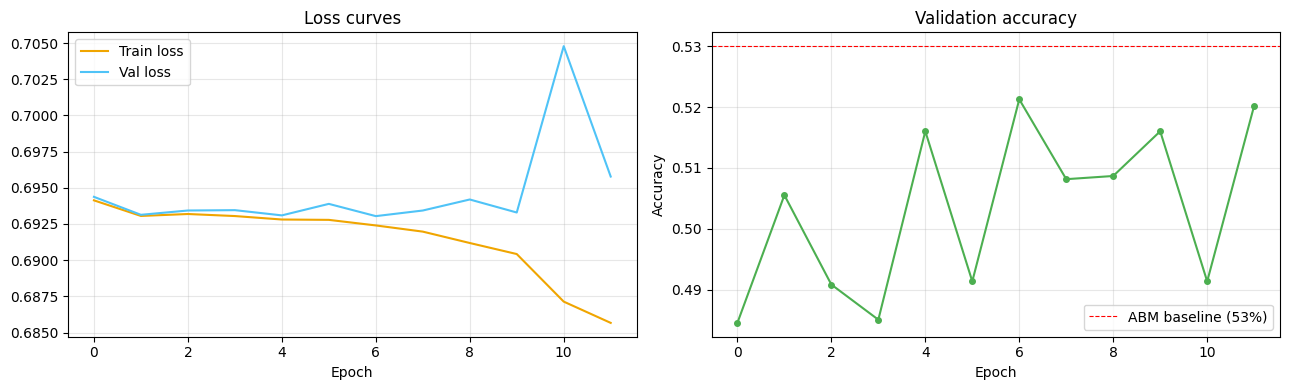

Test set accuracy  : 49.27%
ABM baseline       : 53.00%
Random baseline    : 50.00%
Delta vs ABM       : -3.73pp

Prob distribution  : mean=0.526  std=0.008
(std > 0.05 means model is making confident predictions)

── Notebook 05 complete ──────────────────────────────────────
Next: 06_combined_signal.ipynb

Cell 7 passed ✓


In [7]:
# ── Cell 7: Plot training history + test evaluation ───────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history["train_loss"], label="Train loss", color="#f0a500")
axes[0].plot(history["val_loss"],   label="Val loss",   color="#4fc3f7")
axes[0].set_title("Loss curves")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["val_acc"], color="#4caf50", marker="o", ms=4)
axes[1].axhline(0.53, color="red", lw=0.8, linestyle="--",
                label="ABM baseline (53%)")
axes[1].set_title("Validation accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "tft_training.png", dpi=130)
plt.show()

# ── Test set evaluation ────────────────────────────────────────────────────────
model.load_state_dict(torch.load(CHECKPOINT_DIR / "tft_best.pt",
                                 weights_only=True))
model.eval()

test_correct = test_total = 0
all_probs = []

with torch.no_grad():
    for x_batch, y_batch in test_dl:
        preds       = model(x_batch.to(device))
        predicted   = (preds > 0.5).float()
        test_correct += (predicted == y_batch.to(device)).sum().item()
        test_total   += len(y_batch)
        all_probs.extend(preds.cpu().numpy())

test_acc = test_correct / test_total
print(f"Test set accuracy  : {test_acc:.2%}")
print(f"ABM baseline       : 53.00%")
print(f"Random baseline    : 50.00%")
print(f"Delta vs ABM       : {(test_acc - 0.53)*100:+.2f}pp")
print(f"\nProb distribution  : "
      f"mean={np.mean(all_probs):.3f}  "
      f"std={np.std(all_probs):.3f}")
print("(std > 0.05 means model is making confident predictions)")
print("\n── Notebook 05 complete ──────────────────────────────────────")
print("Next: 06_combined_signal.ipynb")
print("\nCell 7 passed ✓")